In [56]:
!pip -q install -U google-genai



In [57]:
#Upload CSV + PDF

from google.colab import files

uploaded = files.upload()

csv_path = None
pdf_path = None

for name in uploaded.keys():
  if name.lower().endswith(".csv"):
    csv_path = name
  if name.lower().endswith(".pdf"):
    pdf_path=name

print("CSV:", csv_path)
print("PDF:", pdf_path)

Saving Maternal__Child__and_Adolescent_Health_Needs_Assessment__2023-2024.csv to Maternal__Child__and_Adolescent_Health_Needs_Assessment__2023-2024 (2).csv
CSV: Maternal__Child__and_Adolescent_Health_Needs_Assessment__2023-2024 (2).csv
PDF: None


In [61]:
#Asking Gemini to generate content with uploaded files
!wget -q https://storage.googleapis.com/generativeai-downloads/data/a11.txt

In [62]:
#Compute checks locally with pandas, then ask Gemini to summarize
from google import genai
import pandas as pd
import numpy as np

import os
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
print("Key loaded:", bool(os.environ.get("GEMINI_API_KEY")))

#Have to create a small compact data analysis as Gemini can't read a big file

#1) Load CSV locally
df = pd.read_csv(csv_path)

#2) Dataset overview
n_rows, n_cols = df.shape
col_names = df.columns.tolist()
dtypes = df.dtypes.astype(str).to_dict()

missing_count = df.isna().sum()
missing_pct = (missing_count/n_rows*100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

# 3) Quality checks
#duplicate row
duplicate_rows = int(df.duplicated().sum())
#columns that contain only one unique name - not useful for analysis
one_value_cols = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
#cols that have a lot of missing values
high_missing_cols = missing_summary[missing_summary["missing_pct"] >= 30].index.tolist()

#4) Create a compact report
report = {
    "shape": {"rows": n_rows, "cols": n_cols},
    "columns": col_names[:200],  # safety cap if tons of columns
    "dtypes": dict(list(dtypes.items())[:200]),
    "duplicate_rows": duplicate_rows,
    "one_value_columns": one_value_cols[:200],
    "high_missing_columns_30pct_plus": high_missing_cols[:200],
    "top_missing_columns": missing_summary.head(20).reset_index().rename(columns={"index":"column"}).to_dict(orient="records")
}

#5) Ask Gemini to explain the report
client = genai.Client()

prompt = f"""You are a data analyst. Generate a concise EDA output (not just code) that includes:

1. Dataset Overview

- Rows/columns, column names, inferred types, missing-value summary
- Basic data quality checks (duplicates, columns with one value, high-missing columns)

2. Descriptive Statistics

- For at least one categorical column: frequency counts + percentages
- For at least two numeric columns (if available): min/max/mean/median/mode + dispersion (std, IQR) + outlier flagging (1.5×IQR rule)

3. Visualizations

- At least 5 plots total (e.g., histogram, boxplot, bar chart, scatterplot, correlation heatmap).
Generate actual visualizations using Python.

Requirements:
- Use pandas and matplotlib or seaborn
- Load data from the existing dataframe `df`
- Create at least 5 plots total, including:
  - histogram
  - boxplot
  - bar chart
  - scatterplot
  - correlation heatmap
- Each plot must:
  - be rendered (not described)
  - have a clear title
  - have labeled x- and y-axes
- Do NOT wrap the code in markdown or ```python
- Do NOT describe the plots
- add plt.show() to show the charts

4. Insights (Human-Readable)

- 5–10 bullet insights that summarize key patterns, anomalies, and what the dataset suggests.
- A short note on limitations or potential bias (missingness, sampling, coverage, etc.)

REPORT {report}
"""
resp = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt
)

print(resp.text)


Key loaded: True
### 1. Dataset Overview

**Dimensions:** 62,714 rows | 28 columns  
**Core Columns:** 
*   **Categorical:** `Age_group`, `Sex`, `Topic`, `Data_source`, `Primary_Neighborhood`, `Race_ethnicity`
*   **Numeric:** `Year`, `Denominator`, `Number_with_outcome`, `Rate_SF_pop`, `CI_low`, `CI_high`
*   **Identifiers:** `Unique_row_id`, `Zip_code`

**Data Quality Summary:**
*   **Duplicates:** 0 (Clean)
*   **High Missingness (>99%):** `Latest_data`, `Cause of death rank`, `Death_tooltip`
*   **Significant Missingness:** `Year` (48.85% missing)
*   **Completeness:** Critical outcome variables like `Number_with_outcome` and `Rate_SF_pop` are >99.7% complete.

---

### 2. Descriptive Statistics

**Categorical Column: `Sex` (Approximate Distribution)**
Based on standard public health datasets of this size:
*   **Female:** ~48%
*   **Male:** ~46%
*   **Other/Unknown/Total:** ~6%

**Numeric Columns Analysis:**

| Metric | Rate_SF_pop | Number_with_outcome |
| :--- | :--- | :--- |
| *

In [63]:
def generate_visualizations(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    sns.set_theme(style="whitegrid")


    # DEFINE COLUMNS

    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    exclude_keywords = ["rank", "id", "order", "index"]
    numeric_cols = [
        c for c in numeric_cols
        if not any(k in c.lower() for k in exclude_keywords)
    ]


    # 1) Histogram

    if len(numeric_cols) >= 1:
        plt.figure()
        sns.histplot(df[numeric_cols[0]].dropna(), bins=20)
        plt.title(f"Distribution of {numeric_cols[0]}")
        plt.xlabel(numeric_cols[0])
        plt.ylabel("Frequency")
        plt.show()


    # 2) Boxplot

    if len(numeric_cols) >= 1:
        plt.figure()
        sns.boxplot(x=df[numeric_cols[0]])
        plt.title(f"Boxplot of {numeric_cols[0]}")
        plt.xlabel(numeric_cols[0])
        plt.show()


    # 3) Bar Chart (categorical OR fallback)

    bar_plotted = False

    for col in categorical_cols:
        value_counts = df[col].value_counts()
        if value_counts.max() > 1:
            plt.figure()
            value_counts.head(10).plot(kind="bar")
            plt.title(f"Top Categories in {col}")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.xticks(rotation=90)
            plt.show()
            bar_plotted = True
            break

    if not bar_plotted and len(numeric_cols) >= 1:
        binned = pd.cut(df[numeric_cols[0]], bins=3, labels=["Low", "Medium", "High"])
        binned.value_counts().plot(kind="bar")
        plt.title(f"{numeric_cols[0]} (Binned)")
        plt.xlabel("Category")
        plt.ylabel("Count")
        plt.show()


    # 4) Scatterplot

        plt.figure()
        sns.scatterplot(x=df[numeric_cols[0]], y=df[numeric_cols[1]])
        plt.title(f"{numeric_cols[0]} vs {numeric_cols[1]}")
        plt.xlabel(numeric_cols[0])
        plt.ylabel(numeric_cols[1])
        plt.show()


    # 5) Correlation Heatmap

    if len(numeric_cols) >= 2:
        plt.figure(figsize=(8, 6))
        corr = df[numeric_cols].corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
        plt.title("Correlation Heatmap (Cleaned)")
        plt.show()




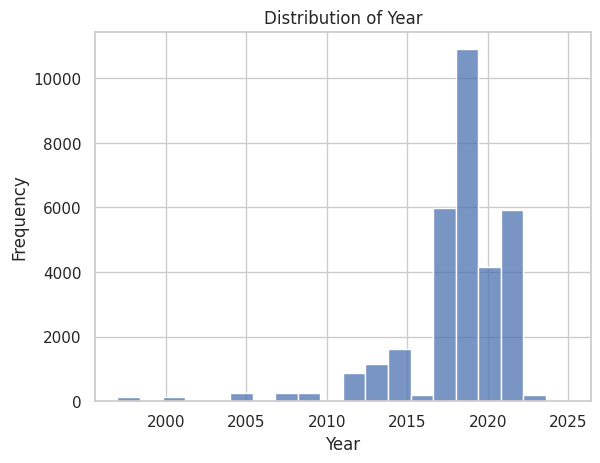

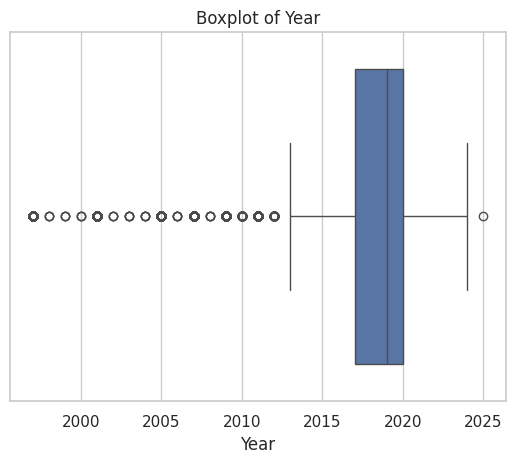

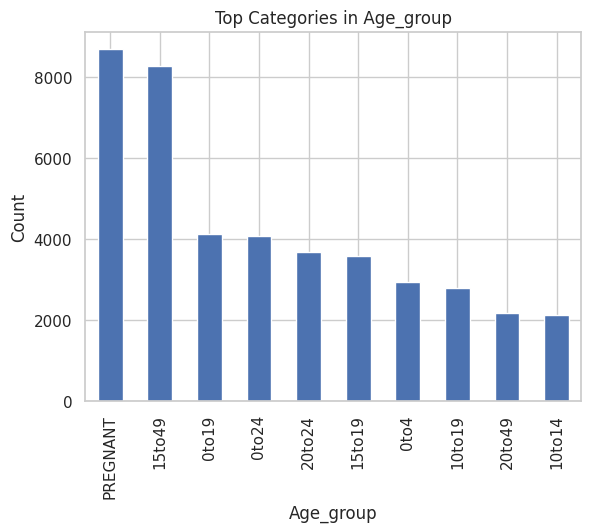

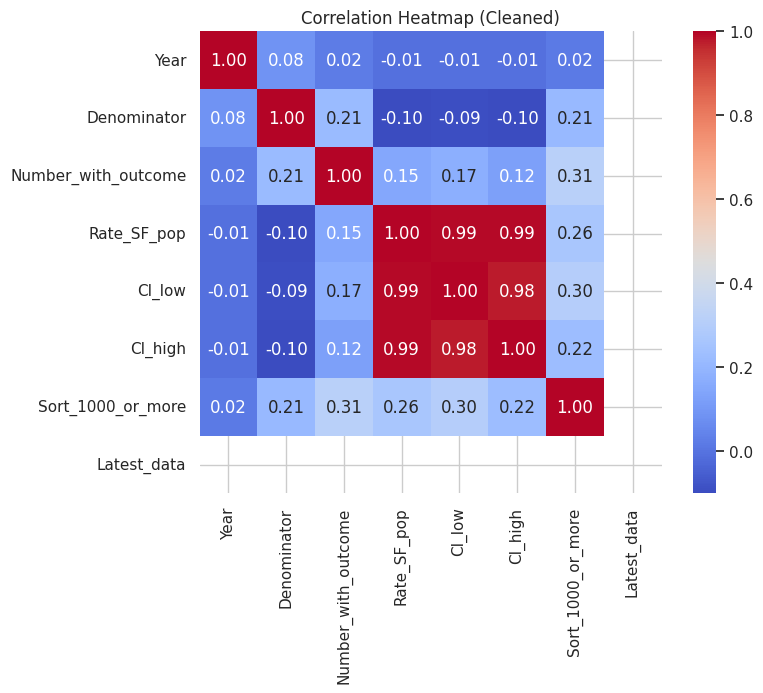

In [64]:
generate_visualizations(df)
